In [1]:
%pip install transformers datasets accelerate evaluate seqeval nlpaug seqeval huggingface_hub torch tqdm rich numpy scikit-learn --quiet
import sys
print(f"Python version: {sys.version}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 17.3 MB/s eta 0:00:00
Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


In [4]:
# Cell 1: Imports and Setup
import json
import logging
import os
import random
import re
from collections import defaultdict, Counter
from typing import List, Dict, Tuple

import evaluate
import matplotlib.pyplot as plt
import numpy as np
import nltk
import pandas as pd
import seaborn as sns
import torch
from datasets import Dataset, DatasetDict
from huggingface_hub import notebook_login
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score,precision_recall_fscore_support
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    Trainer,
    TrainingArguments,
    DataCollatorForTokenClassification,
    EarlyStoppingCallback,
    EvalPrediction,
    pipeline
)
from nlpaug.augmenter.word import SynonymAug

# Set up logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[logging.StreamHandler()],
    force=True
)
logger = logging.getLogger(__name__)

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('punkt')

logger.info("NLTK data downloaded successfully.")

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
logger.info(f"Using device: {device}")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
2025-11-17 04:35:48,945 - INFO - NLTK data downloaded successfully.
2025-11-17 04:35:48,946 - INFO - Using device: cuda


In [5]:
# Cell 2: Load and Explore Dataset
DATASET_PATH = 'dataset.json'  # Replace with actual path if needed

def load_labelstudio_data(file_path: str) -> List[Dict]:
    """Load Label Studio exported JSON dataset."""
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    logger.info(f"Loaded {len(data)} tasks from {file_path}")
    return data

raw_data = load_labelstudio_data(DATASET_PATH)

# Quick exploration
sample_task = raw_data[0]
logger.info(f"Sample task keys: {list(sample_task.keys())}")
logger.info(f"Sample data text preview: {sample_task['data']['text'][:100]}...")

2025-11-17 04:36:03,487 - INFO - Loaded 2238 tasks from dataset.json
2025-11-17 04:36:03,489 - INFO - Sample task keys: ['id', 'annotations', 'drafts', 'predictions', 'data', 'meta', 'created_at', 'updated_at', 'inner_id', 'total_annotations', 'cancelled_annotations', 'total_predictions', 'comment_count', 'unresolved_comment_count', 'last_comment_updated_at', 'project', 'updated_by', 'comment_authors']
2025-11-17 04:36:03,492 - INFO - Sample data text preview: SPDX-License-Identifier: CC-BY-4.0 -->

:warning: Due to changes in the GitHub Search API, these dat...


2025-11-17 04:36:11,786 - INFO - Processed 2238 documents with 3017 entities


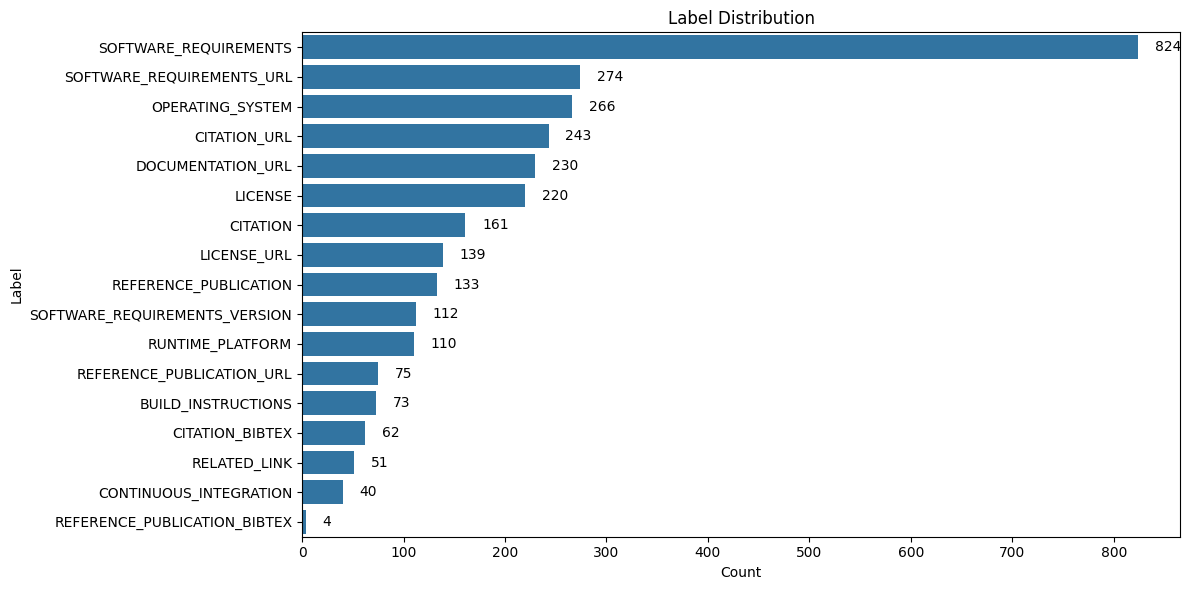

2025-11-17 04:36:12,525 - INFO - Label counts:
                        Label  Count
        SOFTWARE_REQUIREMENTS    824
    SOFTWARE_REQUIREMENTS_URL    274
             OPERATING_SYSTEM    266
                 CITATION_URL    243
            DOCUMENTATION_URL    230
                      LICENSE    220
                     CITATION    161
                  LICENSE_URL    139
        REFERENCE_PUBLICATION    133
SOFTWARE_REQUIREMENTS_VERSION    112
             RUNTIME_PLATFORM    110
    REFERENCE_PUBLICATION_URL     75
           BUILD_INSTRUCTIONS     73
              CITATION_BIBTEX     62
                 RELATED_LINK     51
       CONTINUOUS_INTEGRATION     40
 REFERENCE_PUBLICATION_BIBTEX      4
2025-11-17 04:36:12,533 - INFO - Unique labels: 17
2025-11-17 04:36:12,537 - INFO - Min/Max counts: 4/824 - Imbalance ratio: 206.00


In [6]:
# Cell 3: Extract Entities and Analyze Label Distribution
def extract_entities(data: List[Dict]) -> Tuple[List[Dict], Dict[str, int]]:
    """Extract texts and their entities, return list of {'text': str, 'entities': list} and label counts."""
    processed_data = []
    label_counts = Counter()

    for task in data:
        text = task['data']['text']
        entities = []

        if 'annotations' in task and task['annotations']:
            for ann in task['annotations'][0].get('result', []):
                if 'value' in ann:
                    val = ann['value']
                    entities.append({
                        'start': val['start'],
                        'end': val['end'],
                        'label': val['labels'][0],
                        'text': val['text']
                    })
                    label_counts[val['labels'][0]] += 1

        processed_data.append({'text': text, 'entities': entities})

    logger.info(f"Processed {len(processed_data)} documents with {sum(len(d['entities']) for d in processed_data)} entities")
    return processed_data, dict(label_counts)

processed_data, label_counts = extract_entities(raw_data)

# Visualize label distribution with counts on bars
df_labels = pd.DataFrame(list(label_counts.items()), columns=['Label', 'Count']).sort_values('Count', ascending=False)
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Count', y='Label', data=df_labels)
plt.title('Label Distribution')

# Add count labels to each bar
for i, (count, label) in enumerate(zip(df_labels['Count'], df_labels['Label'])):
    ax.text(count + 0.02 * max(df_labels['Count']),
            i,
            str(count),
            va='center', ha='left', fontsize=10)

plt.tight_layout()
plt.show()

logger.info(f"Label counts:\n{df_labels.to_string(index=False)}")
logger.info(f"Unique labels: {len(label_counts)}")
min_count, max_count = df_labels['Count'].min(), df_labels['Count'].max()
logger.info(f"Min/Max counts: {min_count}/{max_count} - Imbalance ratio: {max_count/min_count:.2f}")

In [7]:
# Cell 4: Only augment documents with ONLY rare labels
AUG_THRESHOLD = 100
AUG_FACTOR = 6
augmenter = SynonymAug(aug_src='wordnet', aug_max=3)

def augment_document_safe(doc: Dict, rare_labels: set, common_labels: set) -> List[Dict]:
    """
    Only augment if document contains rare labels AND no common labels.
    This prevents context augmentation from affecting common label counts.
    """
    doc_labels = {ent['label'] for ent in doc['entities']}

    # Skip if document has ANY common labels (don't mix augmented rare with common)
    if doc_labels & common_labels:
        return [doc]

    # Skip if document has NO rare labels
    if not (doc_labels & rare_labels):
        return [doc]

    augmented = []
    text = doc['text']
    entities = sorted(doc['entities'], key=lambda e: e['start'])

    for _ in range(AUG_FACTOR):
        try:
            parts = []
            last_end = 0

            for ent in entities:
                # Get non-entity text before this entity
                non_ent = text[last_end:ent['start']]
                if non_ent.strip():
                    # Augment the context
                    aug_non_ent = augmenter.augment(non_ent.strip())
                    if isinstance(aug_non_ent, list):
                        aug_non_ent = aug_non_ent[0]
                    parts.append(aug_non_ent)
                else:
                    parts.append('')

                # Always keep entity unchanged
                parts.append(text[ent['start']:ent['end']])
                last_end = ent['end']

            # Handle trailing text
            trailing = text[last_end:].strip()
            if trailing:
                aug_trailing = augmenter.augment(trailing)
                if isinstance(aug_trailing, list):
                    aug_trailing = aug_trailing[0]
                parts.append(aug_trailing)

            new_text = ' '.join(filter(None, parts))

            if len(new_text) < 10:
                continue

            # Re-align entities
            new_entities = []
            offset = 0
            success = True

            for ent in entities:
                search_text = ent['text']
                new_start = new_text.find(search_text, offset)

                if new_start == -1:
                    logger.debug(f"Entity lost: '{search_text}'")
                    success = False
                    break

                new_ent = ent.copy()
                new_ent['start'] = new_start
                new_ent['end'] = new_start + len(search_text)
                new_entities.append(new_ent)
                offset = new_ent['end']

            if success:
                augmented.append({'text': new_text, 'entities': new_entities})

        except Exception as e:
            logger.warning(f"Augmentation failed: {e}")
            continue

    return augmented + [doc]

# Compute label sets
rare_labels = {label for label, count in label_counts.items() if count < AUG_THRESHOLD}
common_labels = {label for label, count in label_counts.items() if count >= AUG_THRESHOLD}

logger.info(f"Rare labels to augment: {rare_labels}")
logger.info(f"Common labels (not to be mixed): {common_labels}")

# Apply augmentation only to pure-rare documents
augmented_data = []
rare_only_docs = 0
mixed_docs = 0

for i, doc in enumerate(processed_data):
    if i % 100 == 0:
        logger.info(f"Processing document {i}/{len(processed_data)}")

    doc_labels = {ent['label'] for ent in doc['entities']}

    if doc_labels & common_labels:
        mixed_docs += 1
        augmented_data.append(doc)  # Keep unchanged
    else:
        rare_only_docs += 1
        augmented_data.extend(augment_document_safe(doc, rare_labels, common_labels))

logger.info(f"Augmentation complete:")
logger.info(f"  - Pure rare-label documents: {rare_only_docs} (augmented)")
logger.info(f"  - Mixed/common documents: {mixed_docs} (kept unchanged)")
logger.info(f"  - Total after augmentation: {len(augmented_data)} (original: {len(processed_data)})")

2025-11-17 04:36:38,535 - INFO - Rare labels to augment: {'REFERENCE_PUBLICATION_BIBTEX', 'RELATED_LINK', 'REFERENCE_PUBLICATION_URL', 'CONTINUOUS_INTEGRATION', 'BUILD_INSTRUCTIONS', 'CITATION_BIBTEX'}
2025-11-17 04:36:38,538 - INFO - Common labels (not to be mixed): {'CITATION', 'LICENSE', 'RUNTIME_PLATFORM', 'SOFTWARE_REQUIREMENTS_URL', 'SOFTWARE_REQUIREMENTS_VERSION', 'REFERENCE_PUBLICATION', 'LICENSE_URL', 'DOCUMENTATION_URL', 'CITATION_URL', 'SOFTWARE_REQUIREMENTS', 'OPERATING_SYSTEM'}
2025-11-17 04:36:38,540 - INFO - Processing document 0/2238
2025-11-17 04:36:38,879 - INFO - Processing document 100/2238
2025-11-17 04:36:39,153 - INFO - Processing document 200/2238
2025-11-17 04:36:39,993 - INFO - Processing document 300/2238
2025-11-17 04:36:40,176 - INFO - Processing document 400/2238
2025-11-17 04:36:40,347 - INFO - Processing document 500/2238
2025-11-17 04:36:40,889 - INFO - Processing document 600/2238
2025-11-17 04:36:40,892 - INFO - Processing document 700/2238
2025-11-17

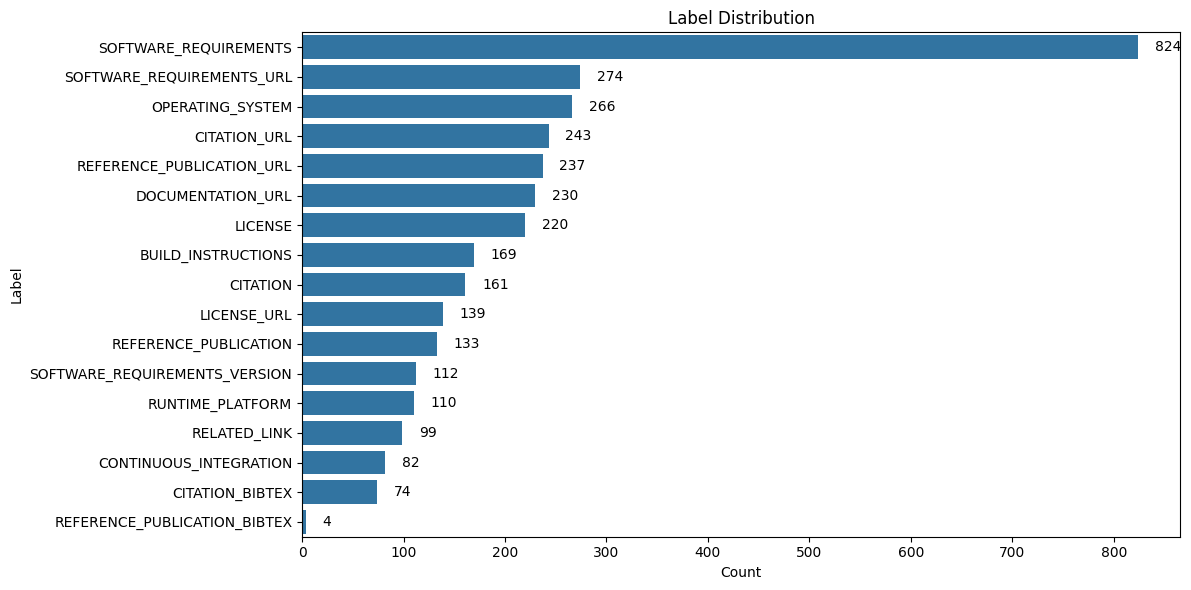

2025-11-17 04:36:52,419 - INFO - Label counts:
                        Label  Count
        SOFTWARE_REQUIREMENTS    824
    SOFTWARE_REQUIREMENTS_URL    274
             OPERATING_SYSTEM    266
                 CITATION_URL    243
    REFERENCE_PUBLICATION_URL    237
            DOCUMENTATION_URL    230
                      LICENSE    220
           BUILD_INSTRUCTIONS    169
                     CITATION    161
                  LICENSE_URL    139
        REFERENCE_PUBLICATION    133
SOFTWARE_REQUIREMENTS_VERSION    112
             RUNTIME_PLATFORM    110
                 RELATED_LINK     99
       CONTINUOUS_INTEGRATION     82
              CITATION_BIBTEX     74
 REFERENCE_PUBLICATION_BIBTEX      4
2025-11-17 04:36:52,424 - INFO - Unique labels: 17
2025-11-17 04:36:52,432 - INFO - Min/Max counts: 4/824 - Imbalance ratio: 206.00


In [8]:
def extract_entities_any(data: List[Dict]) -> Tuple[List[Dict], Dict[str, int]]:
    """Handle both raw (Label Studio) and processed/augmented data."""
    processed_data = []
    label_counts = Counter()

    for task in data:
        if 'data' in task:  # raw format
            text = task['data']['text']
            entities = []
            if 'annotations' in task and task['annotations']:
                for ann in task['annotations'][0].get('result', []):
                    if 'value' in ann:
                        val = ann['value']
                        entities.append({
                            'start': val['start'],
                            'end': val['end'],
                            'label': val['labels'][0],
                            'text': val['text']
                        })
                        label_counts[val['labels'][0]] += 1
        else:  # already processed/augmented format
            text = task['text']
            entities = task.get('entities', [])
            for ent in entities:
                label_counts[ent['label']] += 1

        processed_data.append({'text': text, 'entities': entities})

    return processed_data, dict(label_counts)

_, label_counts_aug = extract_entities_any(augmented_data)

# Visualize label distribution with counts on bars
df_labels = pd.DataFrame(list(label_counts_aug.items()), columns=['Label', 'Count']).sort_values('Count', ascending=False)
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Count', y='Label', data=df_labels)
plt.title('Label Distribution')

# Add count labels to each bar
for i, (count, label) in enumerate(zip(df_labels['Count'], df_labels['Label'])):
    ax.text(count + 0.02 * max(df_labels['Count']),
            i,
            str(count),
            va='center', ha='left', fontsize=10)

plt.tight_layout()
plt.show()

logger.info(f"Label counts:\n{df_labels.to_string(index=False)}")
logger.info(f"Unique labels: {len(label_counts_aug)}")
min_count, max_count = df_labels['Count'].min(), df_labels['Count'].max()
logger.info(f"Min/Max counts: {min_count}/{max_count} - Imbalance ratio: {max_count/min_count:.2f}")

In [9]:
# save the need augmented_data for later loading the same state
with open('augmented_data.json', 'w') as f:
    json.dump(augmented_data, f)
logger.info(f"Augmented data saved to augmented_data.json")

2025-11-17 04:37:15,025 - INFO - Augmented data saved to augmented_data.json


In [ ]:
# load the augmented data in case to reproduce a previous result
#with open('augmented_data.json', 'r') as f:
#    augmented_data = json.load(f)
#logger.info(f"Augmented data loaded from augmented_data.json")

In [10]:
# Cell 5: Prepare Label Mapping and IOB Format
# Create unique labels list, including O
all_labels = sorted(set(label_counts.keys()))
label2id = {label: i for i, label in enumerate(all_labels, start=1)}  # 0 for O
id2label = {i: label for label, i in label2id.items()}
label2id['O'] = 0
id2label[0] = 'O'

NUM_LABELS = len(label2id)
logger.info(f"Number of labels: {NUM_LABELS}")
logger.info(f"Label mapping: {label2id}")

2025-11-17 04:37:21,922 - INFO - Number of labels: 18
2025-11-17 04:37:21,924 - INFO - Label mapping: {'BUILD_INSTRUCTIONS': 1, 'CITATION': 2, 'CITATION_BIBTEX': 3, 'CITATION_URL': 4, 'CONTINUOUS_INTEGRATION': 5, 'DOCUMENTATION_URL': 6, 'LICENSE': 7, 'LICENSE_URL': 8, 'OPERATING_SYSTEM': 9, 'REFERENCE_PUBLICATION': 10, 'REFERENCE_PUBLICATION_BIBTEX': 11, 'REFERENCE_PUBLICATION_URL': 12, 'RELATED_LINK': 13, 'RUNTIME_PLATFORM': 14, 'SOFTWARE_REQUIREMENTS': 15, 'SOFTWARE_REQUIREMENTS_URL': 16, 'SOFTWARE_REQUIREMENTS_VERSION': 17, 'O': 0}


In [11]:
# Cell 6: Tokenize and Align Labels
MODEL_NAME = 'roberta-large'  # User's preferred model
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, add_prefix_space=True)

def tokenize_and_align_labels(examples: Dict) -> Dict:
    """Tokenize texts and align labels to token level (IOB2 format)."""
    tokenized_inputs = tokenizer(
        examples['text'],
        truncation=True,
        max_length=512,
        is_split_into_words=False,  # Since we have char offsets
        return_offsets_mapping=True
    )

    labels = []
    for i, entities in enumerate(examples['entities']):
        offset_mapping = tokenized_inputs.offset_mapping[i]
        label_ids = [0] * len(offset_mapping)  # Default O

        for ent in entities:
            start_char, end_char = ent['start'], ent['end']
            label = ent['label']

            # Find token indices for entity
            start_token = next((j for j, (s, e) in enumerate(offset_mapping) if s <= start_char < e), None)
            end_token = next((j for j, (s, e) in enumerate(offset_mapping) if s < end_char <= e), None)

            if start_token is not None and end_token is not None:
                label_ids[start_token] = label2id[f"B-{label}"] if f"B-{label}" in label2id else label2id[label]  # Assuming BIO, but adjust if IOB2 needed
                for k in range(start_token + 1, end_token + 1):
                    label_ids[k] = label2id[f"I-{label}"] if f"I-{label}" in label2id else label2id[label]

        labels.append(label_ids)

    tokenized_inputs['labels'] = labels
    return tokenized_inputs

# Update label mapping for BIO if needed
# For simplicity, assuming flat labels (no BIO), as many NER setups do for custom. But for overlapping/best, use BIO.
# To enable BIO: Add B- and I- prefixes
bio_labels = ['O'] + [f"B-{l}" for l in all_labels] + [f"I-{l}" for l in all_labels]
label2id = {l: i for i, l in enumerate(bio_labels)}
id2label = {i: l for l, i in label2id.items()}
NUM_LABELS = len(label2id)
logger.info("Using BIO scheme for labels")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

2025-11-17 04:37:30,926 - INFO - Using BIO scheme for labels


In [12]:
# Cell 7: Create Hugging Face Dataset and Split
# Flatten augmented_data into dict for Dataset
hf_data = {
    'text': [d['text'] for d in augmented_data],
    'entities': [d['entities'] for d in augmented_data]
}

dataset = Dataset.from_dict(hf_data)
tokenized_dataset = dataset.map(tokenize_and_align_labels, batched=True, remove_columns=dataset.column_names)

# Split: 80/10/10
train_test = tokenized_dataset.train_test_split(test_size=0.2, seed=SEED)
val_test = train_test['test'].train_test_split(test_size=0.5, seed=SEED)

datasets = DatasetDict({
    'train': train_test['train'],
    'validation': val_test['train'],
    'test': val_test['test']
})

logger.info(f"Dataset splits: {datasets}")

Map:   0%|          | 0/2502 [00:00<?, ? examples/s]

2025-11-17 04:37:43,850 - INFO - Dataset splits: DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'offset_mapping', 'labels'],
        num_rows: 2001
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'offset_mapping', 'labels'],
        num_rows: 250
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'offset_mapping', 'labels'],
        num_rows: 251
    })
})


In [13]:
# Cell 8A: Token-Level Distribution Statistics

from collections import Counter

def count_bio_tokens(tokenized_data):
    """Count all BIO tokens including O."""
    all_labels = []

    for item in tokenized_data:
        labels = item['labels']
        # Convert label IDs back to label names
        label_names = [id2label[label_id] for label_id in labels if label_id != -100]
        all_labels.extend(label_names)

    return Counter(all_labels)

# Count tokens across all splits
train_counts = count_bio_tokens(datasets['train'])
val_counts = count_bio_tokens(datasets['validation'])
test_counts = count_bio_tokens(datasets['test'])

# Combine all splits for overall statistics
all_counts = train_counts + val_counts + test_counts

# Separate O from entity labels
o_count = all_counts.get('O', 0)
entity_counts = {k: v for k, v in all_counts.items() if k != 'O'}
total_entity_tokens = sum(entity_counts.values())
total_tokens = o_count + total_entity_tokens

# Display statistics
print("=" * 70)
print("TOKEN-LEVEL DISTRIBUTION (All Splits Combined)")
print("=" * 70)
print(f"O (Outside) tokens:    {o_count:,} ({o_count/total_tokens*100:.2f}%)")
print(f"Entity tokens (B/I):   {total_entity_tokens:,} ({total_entity_tokens/total_tokens*100:.2f}%)")
print(f"Total tokens:          {total_tokens:,}")
print(f"O:Entity ratio:        {o_count/total_entity_tokens:.2f}:1")
print("=" * 70)

# Per-split breakdown
print("\nPer-Split Breakdown:")
print("-" * 70)
for split_name, counts in [('Train', train_counts), ('Val', val_counts), ('Test', test_counts)]:
    split_o = counts.get('O', 0)
    split_entity = sum(v for k, v in counts.items() if k != 'O')
    split_total = split_o + split_entity
    print(f"{split_name:10} - O: {split_o:,} ({split_o/split_total*100:.1f}%), "
          f"Entities: {split_entity:,} ({split_entity/split_total*100:.1f}%)")
print("=" * 70)

logger.info(f"Token-level imbalance ratio (O:Entity): {o_count/total_entity_tokens:.2f}:1")

2025-11-17 04:37:57,799 - INFO - Token-level imbalance ratio (O:Entity): 10.44:1


TOKEN-LEVEL DISTRIBUTION (All Splits Combined)
O (Outside) tokens:    665,892 (91.26%)
Entity tokens (B/I):   63,754 (8.74%)
Total tokens:          729,646
O:Entity ratio:        10.44:1

Per-Split Breakdown:
----------------------------------------------------------------------
Train      - O: 529,262 (91.1%), Entities: 51,719 (8.9%)
Val        - O: 68,679 (93.2%), Entities: 4,984 (6.8%)
Test       - O: 67,951 (90.6%), Entities: 7,051 (9.4%)


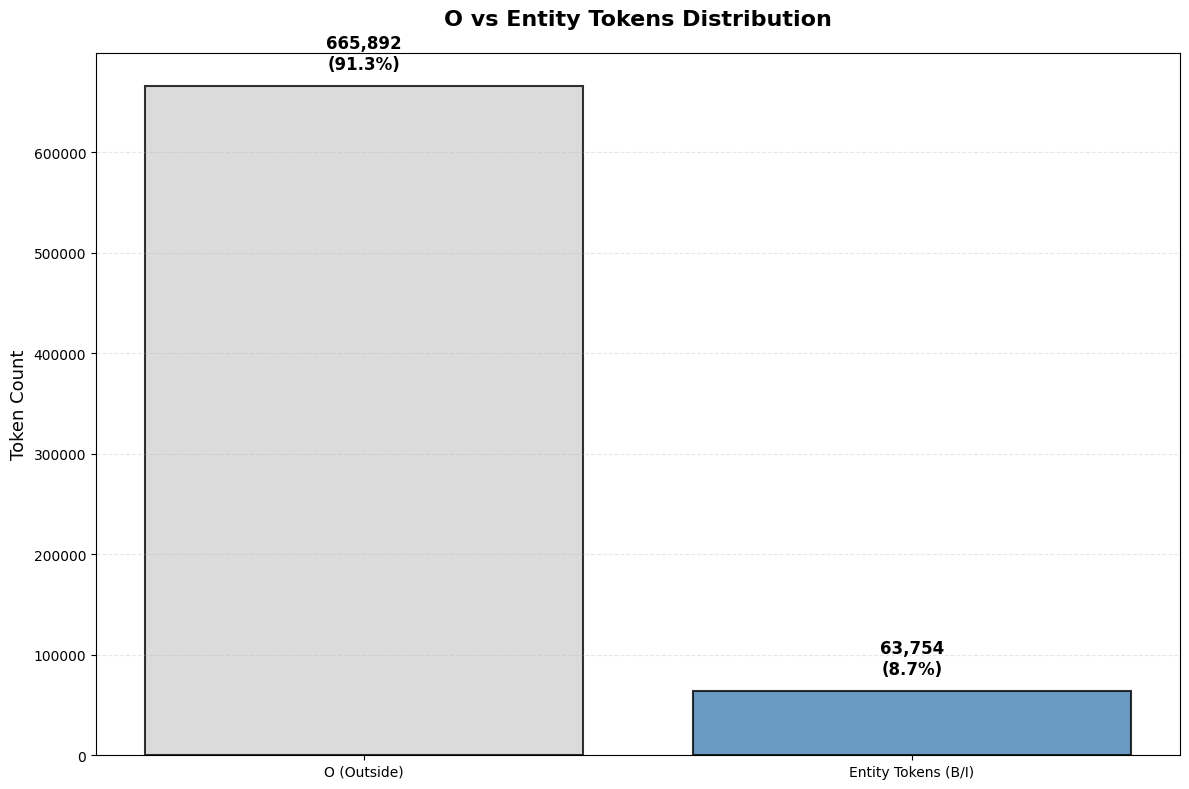

In [14]:
# Cell 8B: O vs Entity Tokens Visualization

import matplotlib.pyplot as plt

# Plot: O vs All Entities combined
categories = ['O (Outside)', 'Entity Tokens (B/I)']
counts = [o_count, total_entity_tokens]
colors = ['lightgray', 'steelblue']

plt.figure(figsize=(12, 8))
bars = plt.bar(categories, counts, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

plt.ylabel('Token Count', fontsize=13)
plt.title('O vs Entity Tokens Distribution', fontsize=16, fontweight='bold', pad=20)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add count labels on bars
for i, (cat, count) in enumerate(zip(categories, counts)):
    plt.text(i, count + max(counts)*0.02,
             f'{count:,}\n({count/total_tokens*100:.1f}%)',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

/tmp/ipython-input-2335498827.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Count', y='Label', data=df_all, palette='viridis')


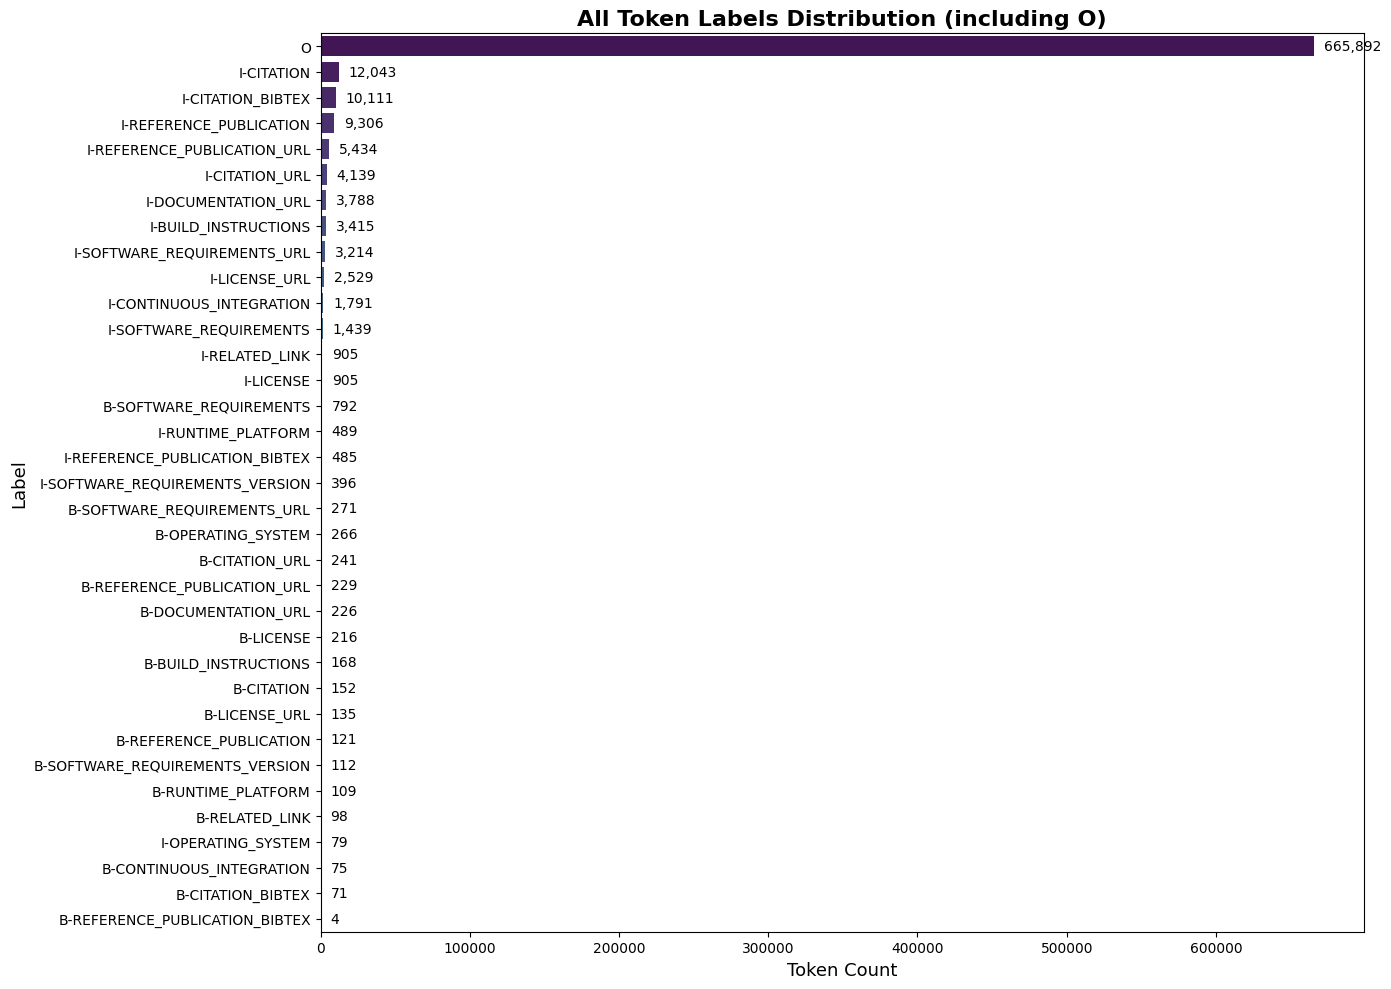

2025-11-17 04:38:42,129 - INFO - Most common label: O with 665,892 tokens
2025-11-17 04:38:42,131 - INFO - Least common label: B-REFERENCE_PUBLICATION_BIBTEX with 4 tokens


In [15]:
# Cell 8C: All BIO Labels Distribution (Including O)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create dataframe with all token counts
df_all = pd.DataFrame(list(all_counts.items()), columns=['Label', 'Count']).sort_values('Count', ascending=False)

plt.figure(figsize=(14, 10))
ax = sns.barplot(x='Count', y='Label', data=df_all, palette='viridis')

plt.title('All Token Labels Distribution (including O)', fontsize=16, fontweight='bold')
plt.xlabel('Token Count', fontsize=13)
plt.ylabel('Label', fontsize=13)

# Add count labels to each bar
for i, (count, label) in enumerate(zip(df_all['Count'], df_all['Label'])):
    ax.text(count + 0.01 * max(df_all['Count']),
            i,
            f'{count:,}',
            va='center', ha='left', fontsize=10)

plt.tight_layout()
plt.show()

# Log summary
logger.info(f"Most common label: {df_all.iloc[0]['Label']} with {df_all.iloc[0]['Count']:,} tokens")
logger.info(f"Least common label: {df_all.iloc[-1]['Label']} with {df_all.iloc[-1]['Count']:,} tokens")

In [16]:
# Cell 8: compute_metrics (FINAL + GUARANTEED LOGGING)

seqeval = evaluate.load("seqeval")

def compute_metrics(p: EvalPrediction):
    preds = np.argmax(p.predictions, axis=2)
    labels = p.label_ids

    # Convert sequences to tag lists
    true_predictions, true_labels = [], []
    for pred_seq, label_seq in zip(preds, labels):
        pred_tags, true_tags = [], []
        for p_i, l_i in zip(pred_seq, label_seq):
            if l_i != -100:
                pred_tags.append(id2label[p_i])
                true_tags.append(id2label[l_i])
        true_predictions.append(pred_tags)
        true_labels.append(true_tags)

    # ===============================
    # seqeval metrics
    # ===============================
    results = seqeval.compute(
        predictions=true_predictions,
        references=true_labels,
        zero_division=0
    )

    metrics_out = {
        "eval_precision": results["overall_precision"],
        "eval_recall": results["overall_recall"],
        "eval_f1": results["overall_f1"],
        "eval_accuracy": results["overall_accuracy"],
    }

    return metrics_out


In [17]:
# Cell 9: Model and Training Setup
model = AutoModelForTokenClassification.from_pretrained(MODEL_NAME,
                                                        num_labels=NUM_LABELS,
                                                        id2label=id2label,
                                                        label2id=label2id,
                                                        hidden_dropout_prob=0.2,
                                                        attention_probs_dropout_prob=0.2
                                                        )
model.to(device)

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=10,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none",
    logging_dir='./logs',
    logging_steps=10,
    save_total_limit=2,
    fp16=torch.cuda.is_available(),
    gradient_accumulation_steps=2,
    warmup_steps=100,
    lr_scheduler_type="linear",
)

data_collator = DataCollatorForTokenClassification(tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=datasets['train'],
    eval_dataset=datasets['validation'],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2,early_stopping_threshold=0.001)]
)

logger.info("Ready to start VROOMMM...")

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaForTokenClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4107720492.py:35: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
2025-11-17 04:39:15,555 - INFO - Ready to start VROOMMM...


In [18]:
# Cell 10: Train the Model
train_results = trainer.train()
trainer.save_model('./best_model')
tokenizer.save_pretrained('./best_model')
logger.info("Training completed")

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.305400,0.259602,0.008895,0.025271,0.013158,0.931282
2,0.192600,0.149132,0.059829,0.151625,0.085802,0.955839
3,0.180400,0.142929,0.127438,0.353791,0.187380,0.954265
4,0.069300,0.147403,0.226048,0.545126,0.319577,0.961704
5,0.113600,0.151071,0.256410,0.685921,0.373281,0.957998
6,0.047300,0.133351,0.288165,0.606498,0.390698,0.968845
7,0.038300,0.145990,0.351494,0.722022,0.472813,0.967569
8,0.028500,0.177217,0.319749,0.736462,0.445902,0.965342
9,0.029400,0.157283,0.372943,0.736462,0.495146,0.967867
10,0.014000,0.161702,0.386064,0.740072,0.507426,0.968464


2025-11-17 05:21:44,908 - INFO - Training completed


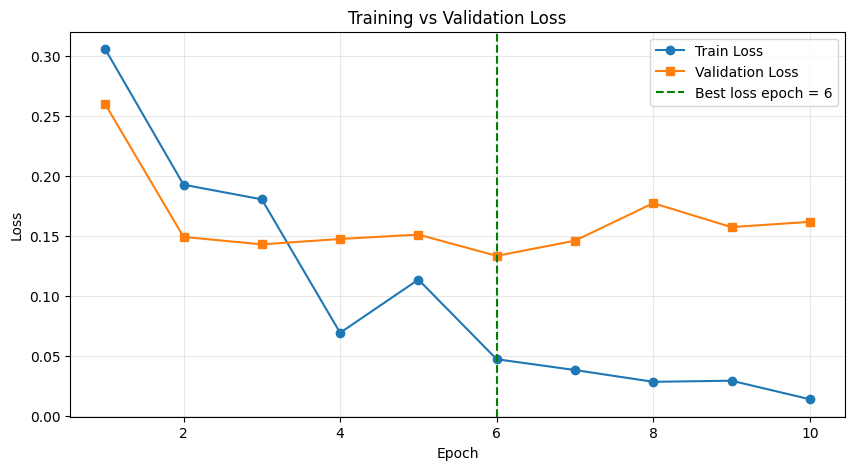

In [19]:
# Cell 11: Loss distribution

log = trainer.state.log_history

# Collect training and eval logs
train_logs = [(i, x["loss"]) for i, x in enumerate(log) if "loss" in x]
eval_logs  = [(i, x["eval_loss"]) for i, x in enumerate(log) if "eval_loss" in x]

# Extract eval loss (one per epoch)
val_loss = [v for (_, v) in eval_logs]

# For each eval index, take the last training loss before it
train_loss = []
for eval_idx, _ in eval_logs:
    prev_train = [tl for (i, tl) in train_logs if i < eval_idx]
    train_loss.append(prev_train[-1] if prev_train else None)

# Fill missing values smoothly
for i in range(len(train_loss)):
    if train_loss[i] is None:
        train_loss[i] = train_loss[i-1] if i > 0 else None

epochs = range(1, len(val_loss) + 1)
best_epoch = min(range(len(val_loss)), key=val_loss.__getitem__) + 1

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_loss, marker='o', label='Train Loss')
plt.plot(epochs, val_loss, marker='s', label='Validation Loss')
plt.axvline(best_epoch, color='green', linestyle='--', label=f'Best loss epoch = {best_epoch}')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

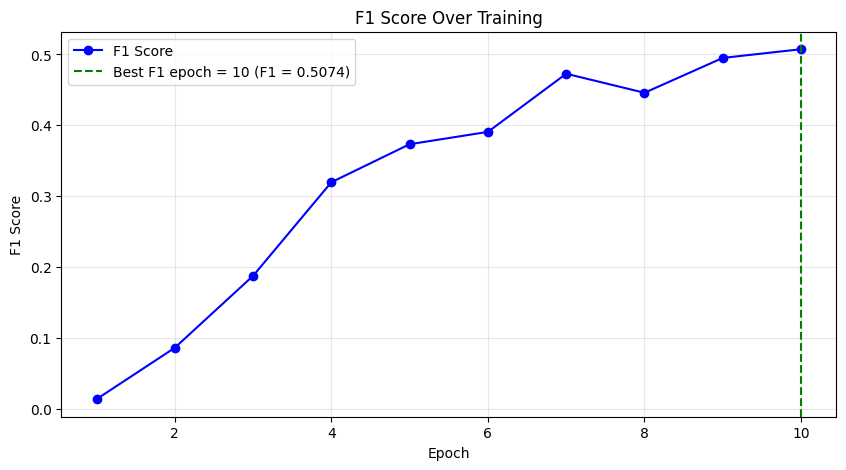

Best F1 Score: 0.5074 at epoch 10


In [20]:
# Cell 12: Best Model F1 Score

log = trainer.state.log_history

# Extract eval logs with F1 scores
eval_logs = [(i, x["eval_f1"]) for i, x in enumerate(log) if "eval_f1" in x]

# Extract F1 scores (one per epoch)
f1_scores = [v for (_, v) in eval_logs]

epochs = range(1, len(f1_scores) + 1)
best_epoch = max(range(len(f1_scores)), key=f1_scores.__getitem__) + 1
best_f1 = f1_scores[best_epoch - 1]

plt.figure(figsize=(10, 5))
plt.plot(epochs, f1_scores, marker='o', label='F1 Score', color='blue')
plt.axvline(best_epoch, color='green', linestyle='--',
            label=f'Best F1 epoch = {best_epoch} (F1 = {best_f1:.4f})')

plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("F1 Score Over Training")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print(f"Best F1 Score: {best_f1:.4f} at epoch {best_epoch}")

In [21]:
# Cell 13: Evaluate on Test Set
pred_output = trainer.predict(datasets["test"])

logger.info(f"Test results: {pred_output.metrics}")

logits = pred_output.predictions
label_ids = pred_output.label_ids

pred_ids = np.argmax(logits, axis=2)

true_labels = []
pred_labels = []

for pred_seq, label_seq in zip(pred_ids, label_ids):
    true_tags = []
    pred_tags = []
    for p, l in zip(pred_seq, label_seq):
        if l != -100:
            true_tags.append(id2label[l])
            pred_tags.append(id2label[p])
    true_labels.append(true_tags)
    pred_labels.append(pred_tags)

# Flatten for token-level classification report
flat_true = [t for seq in true_labels for t in seq]
flat_pred = [t for seq in pred_labels for t in seq]


print(classification_report(flat_true, flat_pred, zero_division=0))


2025-11-17 05:22:16,410 - INFO - Test results: {'test_loss': 0.1052682176232338, 'test_eval_precision': 0.3906810035842294, 'test_eval_recall': 0.7266666666666667, 'test_eval_f1': 0.5081585081585082, 'test_eval_accuracy': 0.9780672515399589, 'test_runtime': 6.404, 'test_samples_per_second': 39.194, 'test_steps_per_second': 4.997}


                                 precision    recall  f1-score   support

           B-BUILD_INSTRUCTIONS       0.71      0.92      0.80        13
                     B-CITATION       0.71      0.92      0.80        13
              B-CITATION_BIBTEX       0.92      0.85      0.88        13
                 B-CITATION_URL       0.94      1.00      0.97        17
       B-CONTINUOUS_INTEGRATION       0.75      0.75      0.75         8
            B-DOCUMENTATION_URL       0.56      0.91      0.69        22
                      B-LICENSE       0.71      1.00      0.83        15
                  B-LICENSE_URL       1.00      1.00      1.00        17
             B-OPERATING_SYSTEM       0.46      0.79      0.58        14
        B-REFERENCE_PUBLICATION       1.00      0.18      0.30        17
    B-REFERENCE_PUBLICATION_URL       0.63      1.00      0.78        19
                 B-RELATED_LINK       0.77      0.83      0.80        12
             B-RUNTIME_PLATFORM       0.61      0.

In [22]:
# save the test dataset in form of dataset to later load
datasets["test"].save_to_disk("./test_dataset")

Saving the dataset (0/1 shards):   0%|          | 0/251 [00:00<?, ? examples/s]

In [ ]:
# Later, load it back
from datasets import load_from_disk
test_dataset = load_from_disk("./test_dataset")

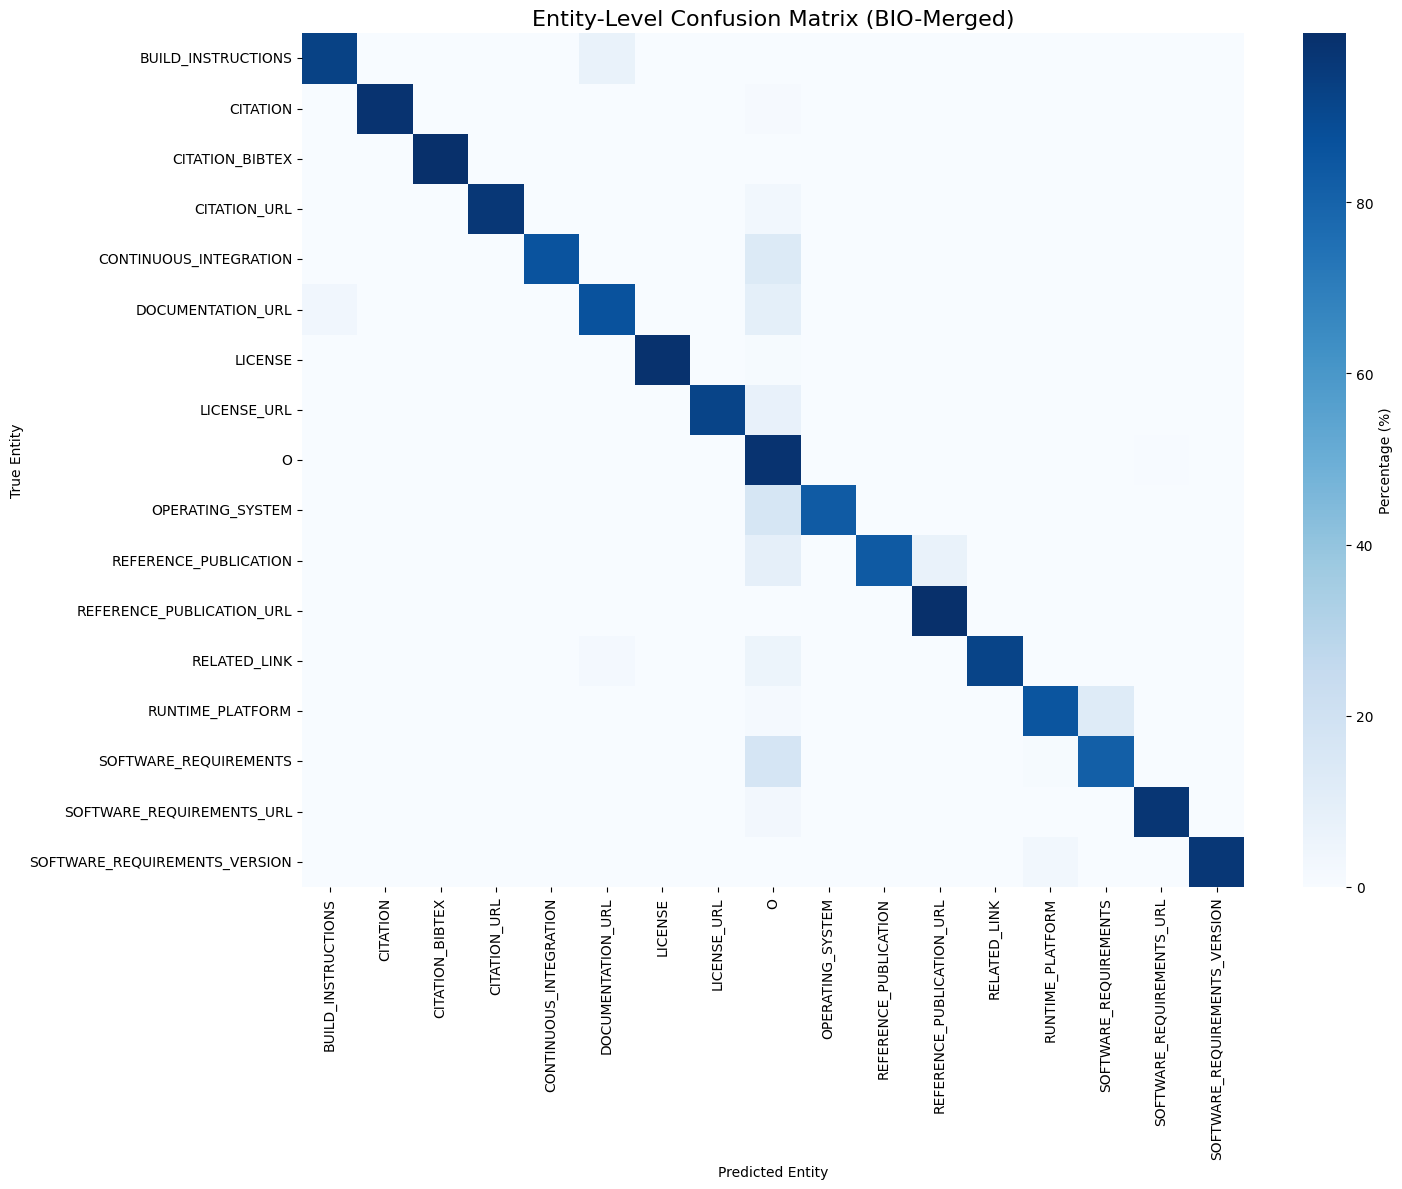

In [23]:
# Cell 14: Grouped Entity Confusion Matrix (BIO merged)

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def base_label(tag):
    """Convert BIO tag (B-XXX/I-XXX) → XXX."""
    if tag == "O":
        return "O"
    return tag.split("-", 1)[-1]

# Convert flattened predictions to entity families
flat_true_base = [base_label(t) for t in flat_true]
flat_pred_base = [base_label(t) for t in flat_pred]

unique_entities = sorted(set(flat_true_base) | set(flat_pred_base))

# Encode as indices
entity_to_index = {lab: i for i, lab in enumerate(unique_entities)}
y_true_ent = [entity_to_index[l] for l in flat_true_base]
y_pred_ent = [entity_to_index[l] for l in flat_pred_base]

# Compute confusion matrix (normalized as percentages)
cm_fam = confusion_matrix(y_true_ent, y_pred_ent, normalize="true") * 100

plt.figure(figsize=(15, 12))
sns.heatmap(
    cm_fam,
    cmap="Blues",
    xticklabels=unique_entities,
    yticklabels=unique_entities,
    annot=False,
    cbar_kws={'label': 'Percentage (%)'}
)

plt.title("Entity-Level Confusion Matrix (BIO-Merged)", fontsize=16)
plt.xlabel("Predicted Entity")
plt.ylabel("True Entity")
plt.tight_layout()
plt.show()

In [24]:
# Cell 14: Detailed Per-Label Metrics

from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get all unique labels (excluding PAD)
all_labels = [lab for lab in id2label.values() if lab != "[PAD]"]

# Get classification report as dictionary
report = classification_report(
    flat_true,
    flat_pred,
    labels=all_labels,
    target_names=all_labels,
    output_dict=True,
    zero_division=0
)

# Convert to DataFrame
df_report = pd.DataFrame(report).transpose()
df_report = df_report[df_report.index.isin(all_labels)]  # Only entity labels
df_report = df_report.sort_values('f1-score', ascending=False)

print("=" * 80)
print("PER-LABEL PERFORMANCE METRICS (Test Set)")
print("=" * 80)
print(df_report[['precision', 'recall', 'f1-score', 'support']].to_string())
print("=" * 80)

# Identify best and worst performers
best_label = df_report['f1-score'].idxmax()
worst_label = df_report['f1-score'].idxmin()
print(f"\n✅ Best performing label: {best_label} (F1={df_report.loc[best_label, 'f1-score']:.4f})")
print(f"❌ Worst performing label: {worst_label} (F1={df_report.loc[worst_label, 'f1-score']:.4f})")
print("=" * 80)

PER-LABEL PERFORMANCE METRICS (Test Set)
                                 precision    recall  f1-score  support
B-LICENSE_URL                     1.000000  1.000000  1.000000     17.0
I-OPERATING_SYSTEM                1.000000  1.000000  1.000000      4.0
O                                 0.995866  0.982075  0.988923  67951.0
I-CITATION                        0.988691  0.981556  0.985111   1247.0
B-CITATION_URL                    0.944444  1.000000  0.971429     17.0
I-CITATION_URL                    0.974432  0.963483  0.968927    356.0
I-CITATION_BIBTEX                 0.919765  0.997347  0.956987   1885.0
I-LICENSE_URL                     0.993443  0.918182  0.954331    330.0
I-LICENSE                         0.913580  0.973684  0.942675     76.0
I-REFERENCE_PUBLICATION           0.983462  0.835989  0.903749   1067.0
B-CITATION_BIBTEX                 0.916667  0.846154  0.880000     13.0
I-RELATED_LINK                    0.766234  0.929134  0.839858    127.0
B-LICENSE              

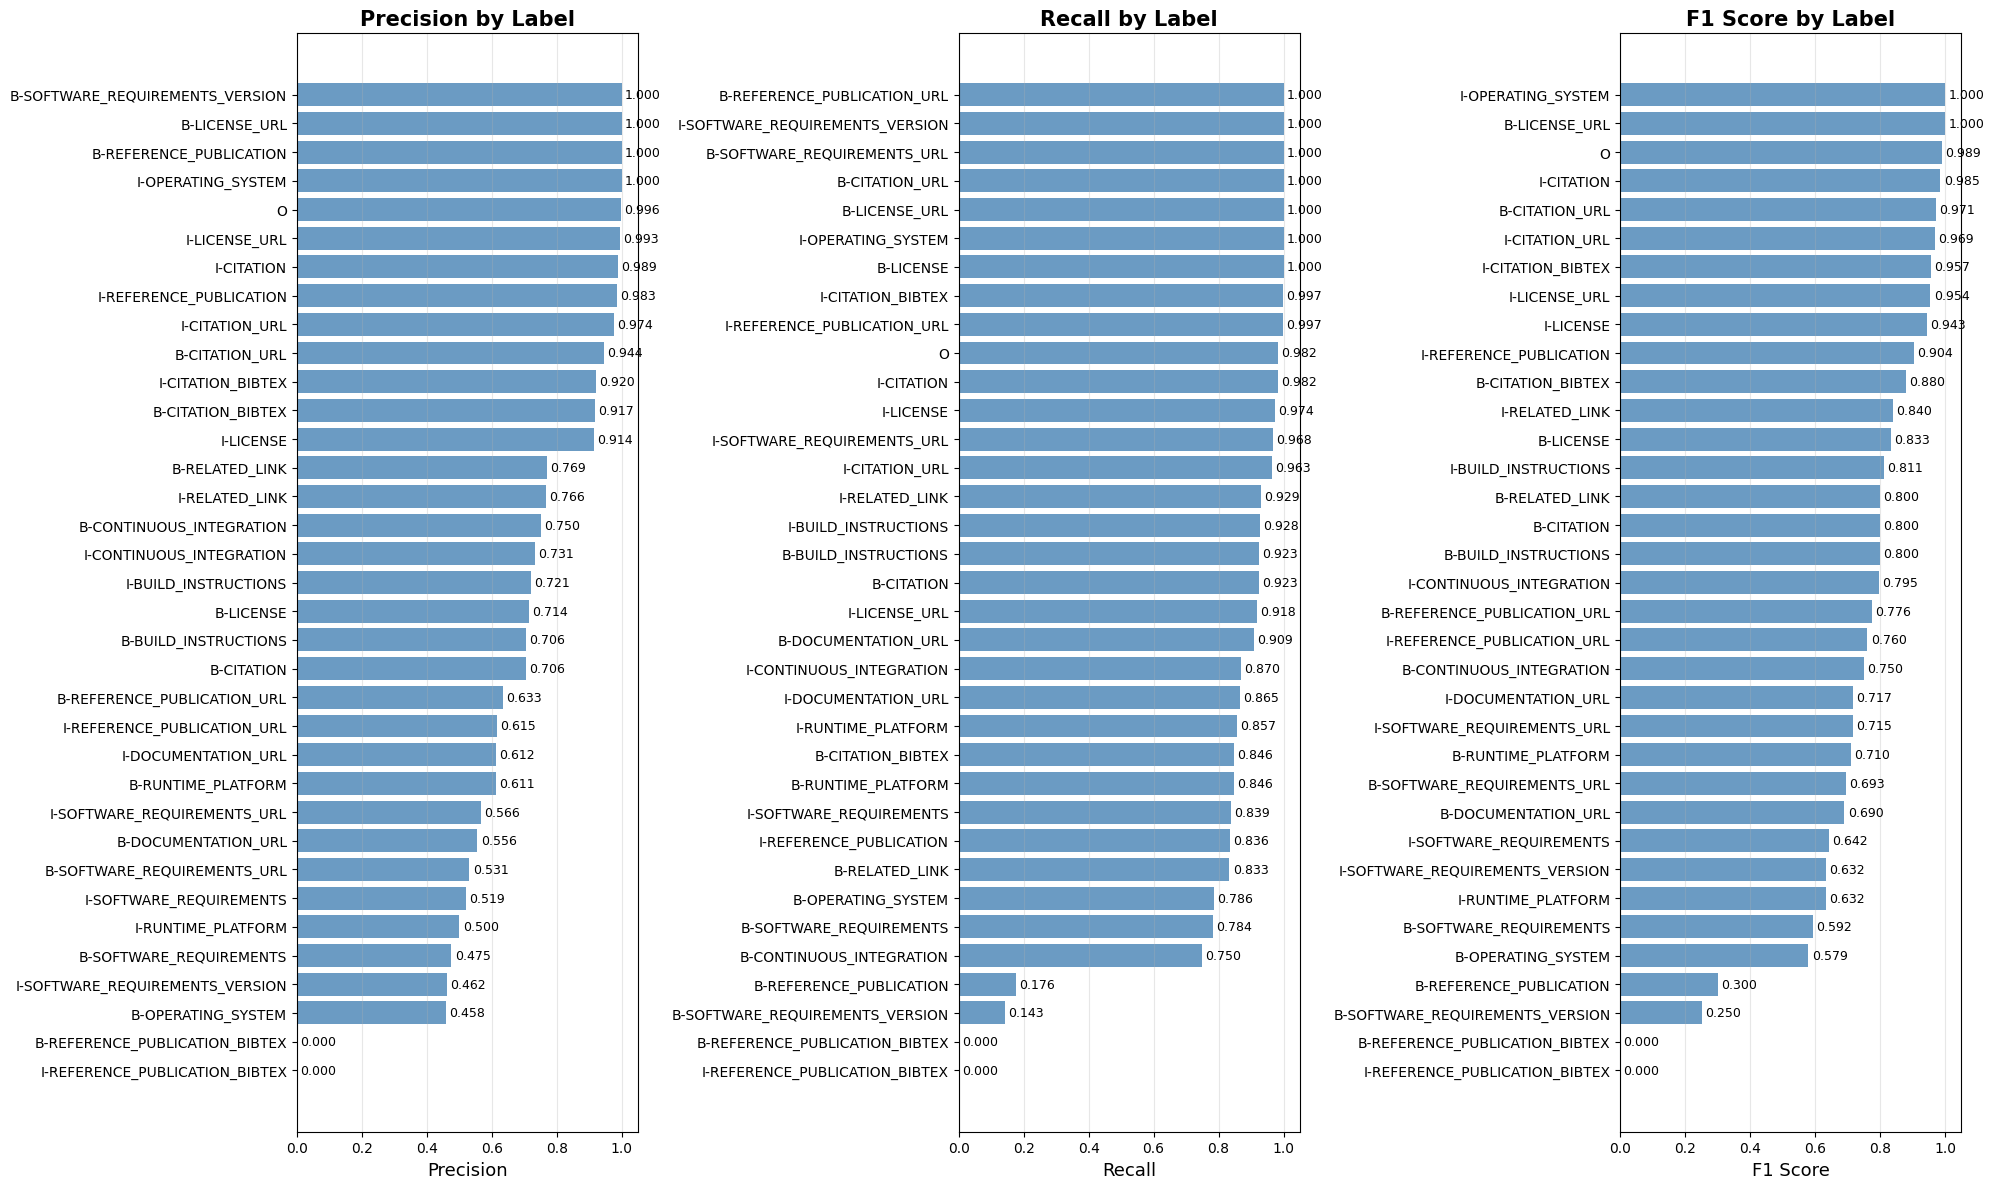

In [25]:
# Cell 15: Visualize Per-Label Metrics

fig, axes = plt.subplots(1, 3, figsize=(20, 12))

for idx, metric in enumerate(['precision', 'recall', 'f1-score']):
    df_sorted = df_report.sort_values(metric, ascending=True)
    axes[idx].barh(df_sorted.index, df_sorted[metric], color='steelblue', alpha=0.8)
    axes[idx].set_xlabel(metric.replace('-', ' ').title(), fontsize=13)
    axes[idx].set_title(f'{metric.replace("-", " ").title()} by Label', fontsize=15, fontweight='bold')
    axes[idx].grid(axis='x', alpha=0.3)
    axes[idx].set_xlim(0, 1.05)

    # Add value labels
    for i, (label, value) in enumerate(zip(df_sorted.index, df_sorted[metric])):
        axes[idx].text(value + 0.01, i, f'{value:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [26]:
# Cell 16: Most Confused Label Pairs Analysis

import numpy as np
from sklearn.metrics import confusion_matrix

# Get only the labels that actually appear in the test set
all_labels = sorted(set(flat_true + flat_pred))
all_labels = [lab for lab in all_labels if lab != "[PAD]"]

print(f"Labels in test set: {len(all_labels)}")
print(f"Labels: {all_labels[:10]}...")  # Show first 10

# Convert labels → indices
label_to_index = {lab: i for i, lab in enumerate(all_labels)}
y_true_idx = [label_to_index[l] for l in flat_true]
y_pred_idx = [label_to_index[p] for p in flat_pred]

# Compute confusion matrix
cm = confusion_matrix(y_true_idx, y_pred_idx)

# Normalize row-wise (%)
cm_normalized = cm.astype(float)
cm_normalized = np.divide(
    cm_normalized,
    cm_normalized.sum(axis=1, keepdims=True),
    out=np.zeros_like(cm_normalized),
    where=cm_normalized.sum(axis=1, keepdims=True) != 0
) * 100

# Verify dimensions match
print(f"Confusion matrix shape: {cm.shape}")
print(f"Number of labels: {len(all_labels)}")

# Get off-diagonal confusion (errors only)
cm_errors = cm_normalized.copy()
np.fill_diagonal(cm_errors, 0)  # Remove correct predictions

# Find top N confused pairs
top_n = 15
confused_pairs = []

for i in range(len(all_labels)):
    for j in range(len(all_labels)):
        if i != j and cm_errors[i, j] > 0:
            confused_pairs.append({
                'True Label': all_labels[i],
                'Predicted As': all_labels[j],
                'Error Rate (%)': cm_errors[i, j],
                'Count': int(cm[i, j])
            })

df_confused = pd.DataFrame(confused_pairs).sort_values('Error Rate (%)', ascending=False).head(top_n)

print("=" * 90)
print(f"TOP {top_n} MOST CONFUSED LABEL PAIRS")
print("=" * 90)
print(df_confused.to_string(index=False))
print("=" * 90)

Labels in test set: 33
Labels: ['B-BUILD_INSTRUCTIONS', 'B-CITATION', 'B-CITATION_BIBTEX', 'B-CITATION_URL', 'B-CONTINUOUS_INTEGRATION', 'B-DOCUMENTATION_URL', 'B-LICENSE', 'B-LICENSE_URL', 'B-OPERATING_SYSTEM', 'B-REFERENCE_PUBLICATION']...
Confusion matrix shape: (33, 33)
Number of labels: 33
TOP 15 MOST CONFUSED LABEL PAIRS
                     True Label                    Predicted As  Error Rate (%)  Count
B-SOFTWARE_REQUIREMENTS_VERSION I-SOFTWARE_REQUIREMENTS_VERSION       71.428571      5
        B-REFERENCE_PUBLICATION         I-REFERENCE_PUBLICATION       58.823529     10
       B-CONTINUOUS_INTEGRATION                               O       25.000000      2
        B-REFERENCE_PUBLICATION                               O       23.529412      4
             B-OPERATING_SYSTEM                               O       21.428571      3
        B-SOFTWARE_REQUIREMENTS                               O       20.270270     15
              B-CITATION_BIBTEX               I-CITATION_BIBTE

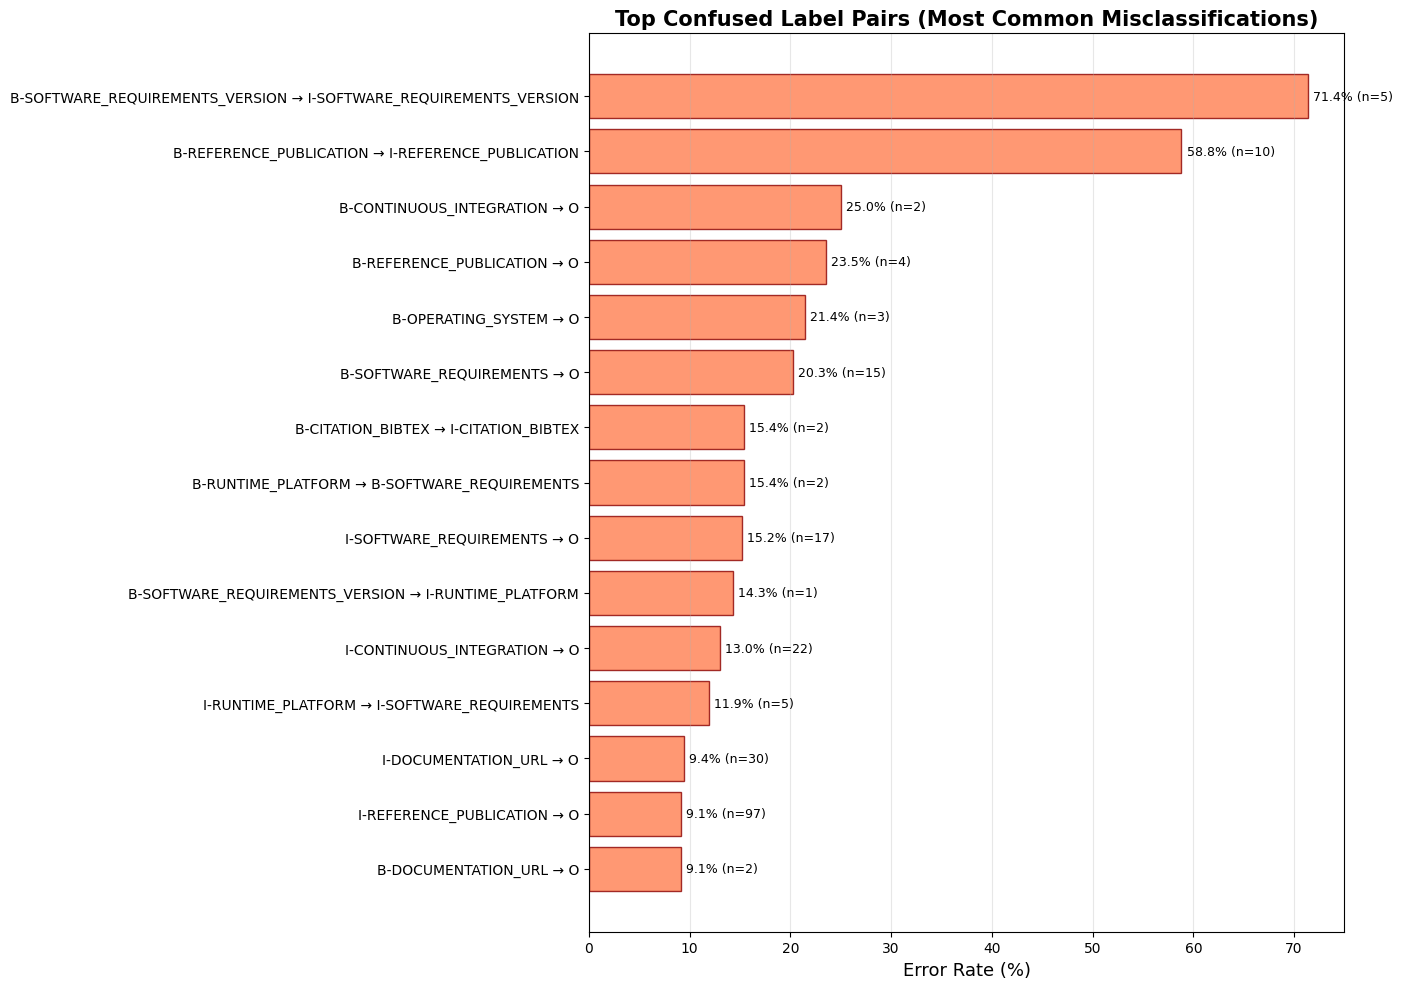

In [29]:
# Cell 17: Visualize Most Confused Pairs

plt.figure(figsize=(14, 10))
df_confused_plot = df_confused.copy()
df_confused_plot['Pair'] = df_confused_plot['True Label'] + ' → ' + df_confused_plot['Predicted As']

bars = plt.barh(df_confused_plot['Pair'], df_confused_plot['Error Rate (%)'],
                color='coral', alpha=0.8, edgecolor='darkred', linewidth=1)

plt.xlabel('Error Rate (%)', fontsize=13)
plt.title('Top Confused Label Pairs (Most Common Misclassifications)', fontsize=15, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)

# Add value labels
for i, (pair, rate, count) in enumerate(zip(df_confused_plot['Pair'],
                                              df_confused_plot['Error Rate (%)'],
                                              df_confused_plot['Count'])):
    plt.text(rate + 0.5, i, f'{rate:.1f}% (n={int(count)})',
             va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [30]:
# Cell 18: Entity-Level Span Evaluation

def extract_entities_from_labels(labels):
    """Extract entity spans from BIO labels."""
    entities = []
    current_entity = None

    for idx, label in enumerate(labels):
        if label.startswith('B-'):
            if current_entity:
                entities.append(current_entity)
            current_entity = {
                'type': label[2:],
                'start': idx,
                'end': idx + 1
            }
        elif label.startswith('I-') and current_entity and label[2:] == current_entity['type']:
            current_entity['end'] = idx + 1
        else:  # O or mismatched I-
            if current_entity:
                entities.append(current_entity)
                current_entity = None

    if current_entity:
        entities.append(current_entity)

    return entities

# Extract entity spans
from collections import defaultdict

entity_tp = defaultdict(int)  # True positives
entity_fp = defaultdict(int)  # False positives
entity_fn = defaultdict(int)  # False negatives

for true_seq, pred_seq in zip(true_labels, pred_labels):
    true_entities = extract_entities_from_labels(true_seq)
    pred_entities = extract_entities_from_labels(pred_seq)

    # Convert to sets for comparison (type, start, end)
    true_set = {(e['type'], e['start'], e['end']) for e in true_entities}
    pred_set = {(e['type'], e['start'], e['end']) for e in pred_entities}

    # Calculate TP, FP, FN per entity type
    for entity in true_set & pred_set:  # Intersection = TP
        entity_tp[entity[0]] += 1

    for entity in pred_set - true_set:  # Predicted but not true = FP
        entity_fp[entity[0]] += 1

    for entity in true_set - pred_set:  # True but not predicted = FN
        entity_fn[entity[0]] += 1

# Calculate metrics
entity_metrics = []
all_entity_types = sorted(set(list(entity_tp.keys()) + list(entity_fp.keys()) + list(entity_fn.keys())))

for ent_type in all_entity_types:
    tp = entity_tp[ent_type]
    fp = entity_fp[ent_type]
    fn = entity_fn[ent_type]

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    entity_metrics.append({
        'Entity Type': ent_type,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Support': tp + fn
    })

df_entity_metrics = pd.DataFrame(entity_metrics).sort_values('F1-Score', ascending=False)

print("=" * 80)
print("ENTITY-LEVEL (SPAN) EVALUATION - Exact Match")
print("=" * 80)
print(df_entity_metrics.to_string(index=False))
print("=" * 80)

# Overall entity-level metrics
total_tp = sum(entity_tp.values())
total_fp = sum(entity_fp.values())
total_fn = sum(entity_fn.values())

overall_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
overall_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
overall_f1 = 2 * overall_precision * overall_recall / (overall_precision + overall_recall) if (overall_precision + overall_recall) > 0 else 0

print(f"\n📊 Overall Entity-Level Performance:")
print(f"   Precision: {overall_precision:.4f}")
print(f"   Recall:    {overall_recall:.4f}")
print(f"   F1-Score:  {overall_f1:.4f}")
print("=" * 80)

ENTITY-LEVEL (SPAN) EVALUATION - Exact Match
                  Entity Type  Precision   Recall  F1-Score  Support
                 CITATION_URL   0.888889 0.941176  0.914286       17
           BUILD_INSTRUCTIONS   0.705882 0.923077  0.800000       13
                 RELATED_LINK   0.769231 0.833333  0.800000       12
                  LICENSE_URL   0.764706 0.764706  0.764706       17
    REFERENCE_PUBLICATION_URL   0.600000 0.947368  0.734694       19
                      LICENSE   0.619048 0.866667  0.722222       15
              CITATION_BIBTEX   0.750000 0.692308  0.720000       13
    SOFTWARE_REQUIREMENTS_URL   0.510204 0.961538  0.666667       26
       CONTINUOUS_INTEGRATION   0.625000 0.625000  0.625000        8
            DOCUMENTATION_URL   0.500000 0.818182  0.620690       22
             OPERATING_SYSTEM   0.458333 0.785714  0.578947       14
        SOFTWARE_REQUIREMENTS   0.442623 0.729730  0.551020       74
             RUNTIME_PLATFORM   0.388889 0.538462  0.45161

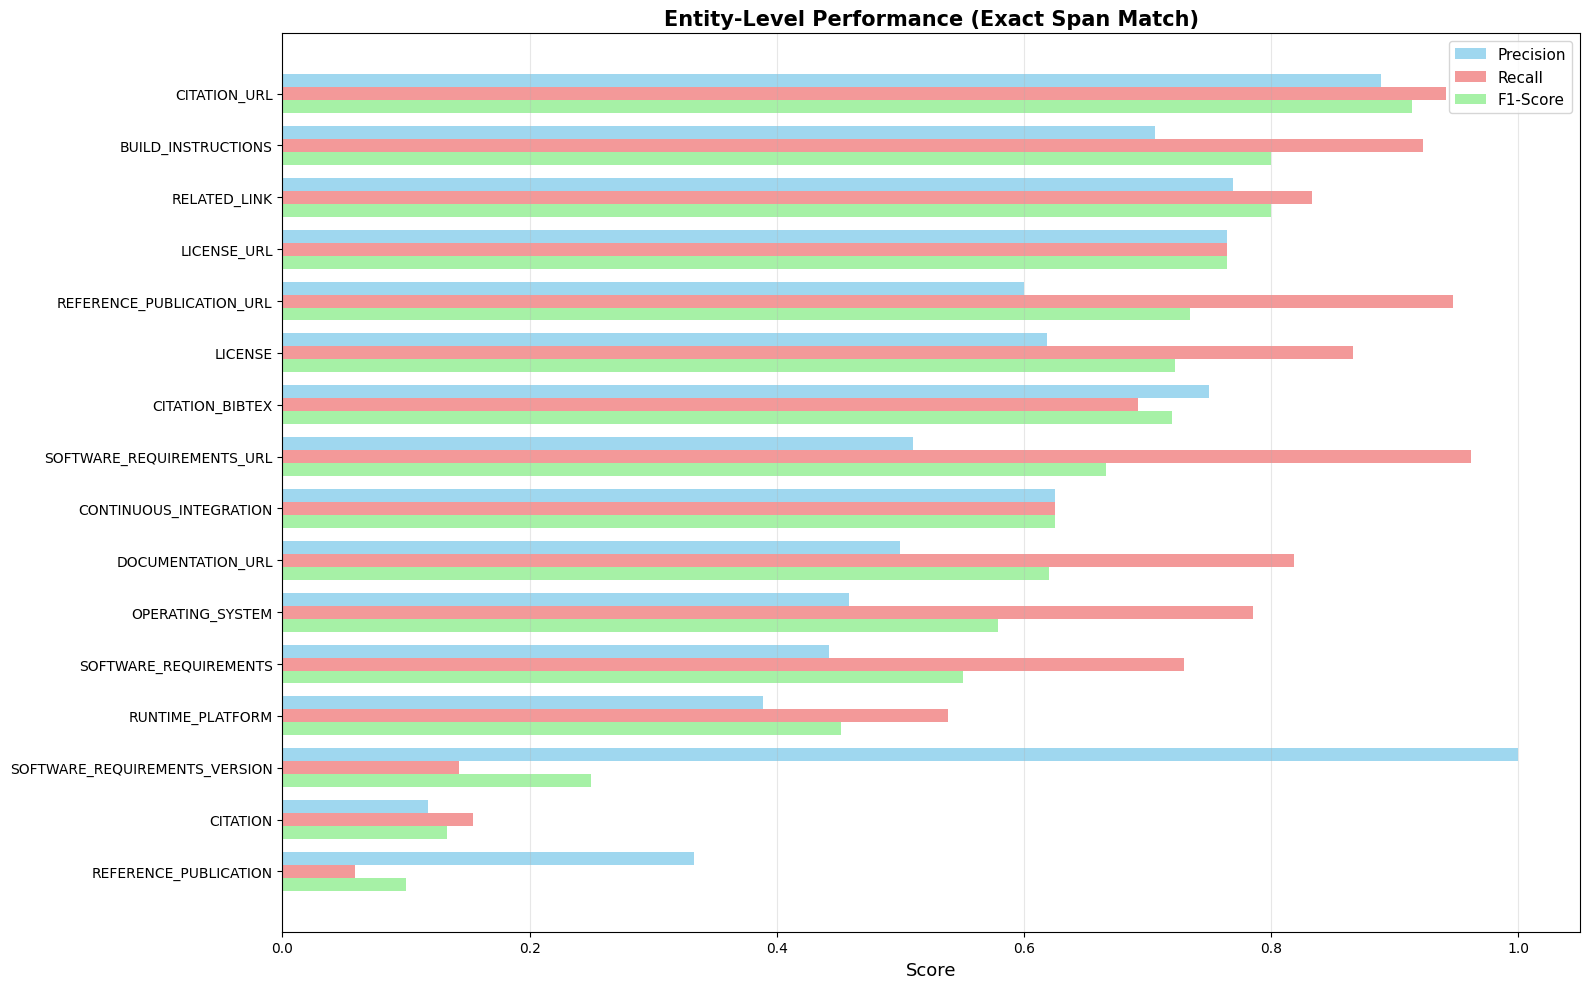

In [31]:
# Cell 19: Visualize Entity-Level Performance

plt.figure(figsize=(16, 10))

x = range(len(df_entity_metrics))
width = 0.25

plt.barh([i - width for i in x], df_entity_metrics['Precision'],
         width, label='Precision', alpha=0.8, color='skyblue')
plt.barh(x, df_entity_metrics['Recall'],
         width, label='Recall', alpha=0.8, color='lightcoral')
plt.barh([i + width for i in x], df_entity_metrics['F1-Score'],
         width, label='F1-Score', alpha=0.8, color='lightgreen')

plt.yticks(x, df_entity_metrics['Entity Type'])
plt.xlabel('Score', fontsize=13)
plt.title('Entity-Level Performance (Exact Span Match)', fontsize=15, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(axis='x', alpha=0.3)
plt.xlim(0, 1.05)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [32]:
# Cell 14: Inference Function with Post-Processing

ner_pipeline = pipeline(
    'ner',
    model='./best_model',          # or the correct directory
    tokenizer='./best_model',
    aggregation_strategy='simple',
    device=0 if torch.cuda.is_available() else -1
)

def infer_and_clean(text: str):
    """Infer entities and apply robust post-cleaning."""
    results = ner_pipeline(text)

    # ----- Merge adjacent tokens -----
    merged = []
    for ent in results:
        if (
            merged and
            merged[-1]['entity_group'] == ent['entity_group'] and
            abs(merged[-1]['end'] - ent['start']) <= 1
        ):
            merged[-1]['word'] += " " + ent['word']
            merged[-1]['end'] = ent['end']
            merged[-1]['score'] = (merged[-1]['score'] + ent['score']) / 2
        else:
            merged.append(ent)

    # ----- Post-cleaning -----
    cleaned = []
    for ent in merged:

        # Score threshold: keep slightly lower values
        if ent['score'] < 0.50:
            continue

        # Remove extremely short tokens (noise)
        if len(ent['word']) < 3:
            continue

        # URL validation
        if 'URL' in ent['entity_group']:
            if not re.search(r'https?://|www\.|doi|\.com|\.org|\.io', ent['word'], re.I):
                continue

        # Optional citation cleaning (avoid being too aggressive)
        if 'CITATION' in ent['entity_group']:
            if len(ent['word']) < 5:
                continue

        cleaned.append(ent)

    return cleaned


# ---- TEST ----
sample_text = raw_data[2]['data']['text'][:1000]
extracted = infer_and_clean(sample_text)
logger.info(f"Extracted entities: {extracted}")
print(f"Extracted entities: {sample_text}")

Device set to use cuda:0
2025-11-17 05:26:42,797 - INFO - Extracted entities: [{'entity_group': 'RUNTIME_PLATFORM', 'score': np.float32(0.8527326), 'word': 'Node.js (version 12 or higher)', 'start': 693, 'end': 723}, {'entity_group': 'SOFTWARE_REQUIREMENTS', 'score': np.float32(0.9447879), 'word': 'npm', 'start': 725, 'end': 728}, {'entity_group': 'SOFTWARE_REQUIREMENTS', 'score': np.float32(0.8206601), 'word': 'Node Package Manager', 'start': 730, 'end': 750}, {'entity_group': 'SOFTWARE_REQUIREMENTS', 'score': np.float32(0.94270855), 'word': 'TypeScript', 'start': 753, 'end': 763}]


Extracted entities: FHIR Cohort Data Transformer

The FHIR Cohort Data Transformer is a TypeScript tool designed to transform cohort-study data into FHIR-compliant data. This tool allows you to specify and test the pairing rules between the cohort-study data and the properties of a given FHIR resource. Once you have defined these rules, you can link them to one or more FHIR-compliant templates.

## Features

Transform cohort-study data into FHIR-compliant data

Allows the definition of pairing rules between cohort-study data and FHIR resource properties

Paring rules are specified in independent modules to make them testeable

## Prerequisites

To use this tool, ensure you have the following installed:

Node.js (version 12 or higher)

npm (Node Package Manager)

TypeScript (installed globally)

## Installation

Clone the repository from GitHub:

git clone https://github.com/your-username/fhir-cohort-data-transformer.git

Navigate to the project directory:

cd fhir-cohort-data-transform

In [ ]:
rm -rf results logs best_model


In [ ]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()


del model
del trainer
try:
    del tokenizer
    del datasets
except:
    pass

gc.collect()
torch.cuda.empty_cache()


In [ ]:
import os
os._exit(00)

In [33]:
!zip -r /content/model.zip /content/best_model/

  adding: content/best_model/ (stored 0%)
  adding: content/best_model/merges.txt (deflated 53%)
  adding: content/best_model/tokenizer.json (deflated 82%)
  adding: content/best_model/tokenizer_config.json (deflated 75%)
  adding: content/best_model/special_tokens_map.json (deflated 52%)
  adding: content/best_model/config.json (deflated 70%)
  adding: content/best_model/vocab.json (deflated 59%)
  adding: content/best_model/training_args.bin (deflated 53%)
  adding: content/best_model/model.safetensors (deflated 9%)


In [34]:
from google.colab import files
files.download('/content/model.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [35]:
!zip -r /content/test_dataset.zip /content/test_dataset/

  adding: content/test_dataset/ (stored 0%)
  adding: content/test_dataset/dataset_info.json (deflated 73%)
  adding: content/test_dataset/data-00000-of-00001.arrow (deflated 84%)
  adding: content/test_dataset/state.json (deflated 38%)


In [36]:
files.download('/content/test_dataset.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>